<a href="https://colab.research.google.com/github/stephanie465337/Data-Science-Portfolio-C21/blob/main/Projects/Project-5/Wiki_Pass_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Wikipedia NLP Clustering

##Problem Definition

##Data Collection

In [1]:
%%capture install_output
%%bash

# Install textblob and download corpora
pip install -q -U textblob
pip install -q -U textblob googletrans==4.0.0-rc1 # [cmd+/] When you get to Translation section.
python -m textblob.download_corpora silent

In [2]:
%%capture output
#install Wikipedia API
!pip3 install wikipedia-api

In [3]:
%%capture
!python -m textblob.download_corpora

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import wikipediaapi
import ipywidgets as widgets

from textblob import TextBlob #Tokenization, Counting words, Parts of Speech Sentiment Analysis
from sklearn.feature_extraction.text import CountVectorizer #Understand Bag of Words
from sklearn.feature_extraction.text import TfidfVectorizer #Final Representation
from sklearn.neighbors import NearestNeighbors #Primary algorithm
from IPython.display import display

In [5]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv'
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv'

In [6]:
df = pd.read_csv(url)
df

,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...
...,...,...,...
42781,<http://dbpedia.org/resource/Motoaki_Takenouchi>,Motoaki Takenouchi,motoaki takenouchi born july 8 1967 saitama pr...
42782,<http://dbpedia.org/resource/Alan_Judge_(footb...,"Alan Judge (footballer, born 1960)",alan graham judge born 14 may 1960 is a retire...
42783,<http://dbpedia.org/resource/Eduardo_Lara>,Eduardo Lara,eduardo lara lozano born 4 september 1959 in c...
42784,<http://dbpedia.org/resource/Tatiana_Faberg%C3...,Tatiana Faberg%C3%A9,tatiana faberg is an author and faberg scholar...


##Data Cleaning

In [7]:
df.shape

(42786, 3)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42786 entries, 0 to 42785
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   URI     42786 non-null  object
 1   name    42786 non-null  object
 2   text    42786 non-null  object
dtypes: object(3)
memory usage: 1002.9+ KB


###Missing Values

In [9]:
df.isnull().sum()

,0
URI,0
name,0
text,0


###Duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['name'].duplicated().sum()

np.int64(1)

In [12]:
df[df['name'].duplicated(keep=False)]

,URI,name,text
787,<http://dbpedia.org/resource/James_Grieve_(tra...,author),james grieve born 1934 is an australian transl...
17249,<http://dbpedia.org/resource/Steve_Greenberg_(...,author),steve greenberg december 20 1960 is an america...


In [13]:
df['URI'].duplicated().sum()

np.int64(0)

In [14]:
(df['text'].str.strip() == '').sum()

np.int64(0)

In [15]:
#Remove extra whitespace
# df['text' = df['text'].str.strip()]

In [16]:
from textblob import TextBlob

tokenized_text = []

for text in df['text']:
  blob = TextBlob(text)
  tokenized_text.append(blob.words)

In [17]:
df['word_count'] = df['text'].apply(
    lambda x: len(TextBlob(x).words)
)

df[['name', 'word_count']].head()

,name,word_count
0,Digby Morrell,251
1,Alfred J. Lewy,223
2,Harpdog Brown,226
3,Franz Rottensteiner,377
4,G-Enka,201


In [19]:
df['name'].sample(1)

,name
27495,Daniel Currie


In [33]:
reference_person = 'Daniel Currie'

person = df[df['name'] == reference_person]

if person.empty:
  print('Person not found.')
else:
  reference_text = person['text'].iloc[0]
  blob = TextBlob(reference_text)
  print(blob.sentiment)

Sentiment(polarity=0.015714285714285712, subjectivity=0.5157142857142857)


In [27]:
print(reference_text[:500])

daniel currie born 15 february 1989 is an australian rules footballer playing for the north melbourne in the australian football league currie was originally drafted to the sydney swans with the 49th selection in the 2006 afl draft but was delisted by the swans at the end of 2011 without having made his afl debutthrough the years of 2007 2008 and 2009 currie sustained numerous and injuries whilst plying his trade in the reserves his 2010 season was much improved however as he managed to finally 


In [28]:
blob.words

WordList(['daniel', 'currie', 'born', '15', 'february', '1989', 'is', 'an', 'australian', 'rules', 'footballer', 'playing', 'for', 'the', 'north', 'melbourne', 'in', 'the', 'australian', 'football', 'league', 'currie', 'was', 'originally', 'drafted', 'to', 'the', 'sydney', 'swans', 'with', 'the', '49th', 'selection', 'in', 'the', '2006', 'afl', 'draft', 'but', 'was', 'delisted', 'by', 'the', 'swans', 'at', 'the', 'end', 'of', '2011', 'without', 'having', 'made', 'his', 'afl', 'debutthrough', 'the', 'years', 'of', '2007', '2008', 'and', '2009', 'currie', 'sustained', 'numerous', 'and', 'injuries', 'whilst', 'plying', 'his', 'trade', 'in', 'the', 'reserves', 'his', '2010', 'season', 'was', 'much', 'improved', 'however', 'as', 'he', 'managed', 'to', 'finally', 'get', 'his', 'body', 'right', 'and', 'play', 'the', 'vast', 'majority', 'of', 'the', 'year', 'he', 'was', 'unable', 'to', 'break', 'into', 'the', 'seniors', 'side', 'due', 'to', 'the', 'emergence', 'of', 'mike', 'pyke', 'and', 'the

In [29]:
blob.tags

[('daniel', 'NN'),
 ('currie', 'NN'),
 ('born', 'VBN'),
 ('15', 'CD'),
 ('february', 'JJ'),
 ('1989', 'CD'),
 ('is', 'VBZ'),
 ('an', 'DT'),
 ('australian', 'JJ'),
 ('rules', 'NNS'),
 ('footballer', 'VBP'),
 ('playing', 'VBG'),
 ('for', 'IN'),
 ('the', 'DT'),
 ('north', 'JJ'),
 ('melbourne', 'NN'),
 ('in', 'IN'),
 ('the', 'DT'),
 ('australian', 'JJ'),
 ('football', 'NN'),
 ('league', 'NN'),
 ('currie', 'NN'),
 ('was', 'VBD'),
 ('originally', 'RB'),
 ('drafted', 'VBN'),
 ('to', 'TO'),
 ('the', 'DT'),
 ('sydney', 'NN'),
 ('swans', 'VBZ'),
 ('with', 'IN'),
 ('the', 'DT'),
 ('49th', 'CD'),
 ('selection', 'NN'),
 ('in', 'IN'),
 ('the', 'DT'),
 ('2006', 'CD'),
 ('afl', 'NN'),
 ('draft', 'NN'),
 ('but', 'CC'),
 ('was', 'VBD'),
 ('delisted', 'VBN'),
 ('by', 'IN'),
 ('the', 'DT'),
 ('swans', 'NNS'),
 ('at', 'IN'),
 ('the', 'DT'),
 ('end', 'NN'),
 ('of', 'IN'),
 ('2011', 'CD'),
 ('without', 'IN'),
 ('having', 'VBG'),
 ('made', 'VBN'),
 ('his', 'PRP$'),
 ('afl', 'JJ'),
 ('debutthrough', 'IN'),
 ('

In [31]:
len(blob.words)

206

In [34]:
cleaned_text = []

for text in df['text']:
  blob = TextBlob(text)

  tokens = [word.lower() for word in blob.words]

  cleaned_text.append(' '.join(tokens))

df['clean_text'] = cleaned_text

In [35]:
df['clean_text']

,clean_text
0,digby morrell born 10 october 1979 is a former...
1,alfred j lewy aka sandy lewy graduated from un...
2,harpdog brown is a singer and harmonica player...
3,franz rottensteiner born in waidmannsfeld lowe...
4,henry krvits born 30 december 1974 in tallinn ...
...,...
42781,motoaki takenouchi born july 8 1967 saitama pr...
42782,alan graham judge born 14 may 1960 is a retire...
42783,eduardo lara lozano born 4 september 1959 in c...
42784,tatiana faberg is an author and faberg scholar...


In [36]:
df['text']

,text
0,digby morrell born 10 october 1979 is a former...
1,alfred j lewy aka sandy lewy graduated from un...
2,harpdog brown is a singer and harmonica player...
3,franz rottensteiner born in waidmannsfeld lowe...
4,henry krvits born 30 december 1974 in tallinn ...
...,...
42781,motoaki takenouchi born july 8 1967 saitama pr...
42782,alan graham judge born 14 may 1960 is a retire...
42783,eduardo lara lozano born 4 september 1959 in c...
42784,tatiana faberg is an author and faberg scholar...


#NLP Preprocessing

##Part 1 - Reference Person

1. Pick one person from the list ( the reference person ) and output 10 other people who's overview are "closest" to the reference person in a Natural Language Processing sense
2. Also output the sentiment of the overview of the reference person


In [37]:
df['name'].sample(1)

,name
12792,L. Desaix Anderson


In [52]:
reference_person = 'L. Desaix Anderson'

person = df[df['name'] == reference_person]

if person.empty:
  print('Person not found.')
else:
  reference_text = person['text'].iloc[0]

blob.sentences

[Sentence("l desaix anderson born 1936 is a career united states foreign service officer specializing in east asian affairs and served as american charg daffaires ad interim to vietnammr anderson a 35year veteran of the us foreign service spent most of his career working on asian issues he was the first envoy to the socialist republic of vietnam following establishment of diplomatic relations serving as charg daffaires from august 1995 when the embassy opened until 1997mr anderson was born in 1936 and was raised on a farm in rural mississippi he received his ba in history from princeton university and did graduate work in european literature at the university of california at berkeley he also served on active duty as an officer in the us navy from 1958 to 1960 after which he managed his family farm in mississippihe entered the foreign service in 1962 his first assignment was in kathmandu nepal as general services officer 196364 mr anderson was assigned to vietnam as an aid provincial r

###Bag of Words (CountVectorizer)

In [56]:
bow = CountVectorizer(stop_words='english')
bow_matrix = bow.fit_transform(df['text'])

print('Bag of Words shape:', bow_matrix.shape)
print('TF-IDF shape:', tfidf_matrix.shape)

Bag of Words shape: (42786, 437190)
TF-IDF shape: (42786, 437190)


###Text Representation (TF-IDF)


**Why TF-IDF?** It gives more importance to meaningful words and less importance to common words like "the", "and", and "of". This makes biographies easier to compare.

In [43]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['text'])

###Similarity Search (KNN)

In [44]:
knn = NearestNeighbors(
    n_neighbors=11,
    metric='cosine'
)

knn.fit(tfidf_matrix)

NearestNeighbors(metric='cosine', n_neighbors=11)

In [45]:
reference_index = df[df['name'] == reference_person].index[0]

In [46]:
distances, indices = knn.kneighbors(tfidf_matrix[reference_index])

In [47]:
results = pd.DataFrame({
    'Name': df.iloc[indices[0][1:]]['name'].values,
    'Distance': distances[0][1:]
})

results

,Name,Distance
0,Eric G. John,0.728602
1,Douglas L. McElhaney,0.735135
2,Peter Tarnoff,0.753984
3,"Harvey Frans Nelson, Jr.",0.755715
4,Bud Anderson (baseball),0.770904
5,Andrey Tatarinov,0.771154
6,David A. Korn,0.778439
7,David Anderson (British Columbia politician),0.785087
8,Ralph L. Boyce,0.788317
9,Diane Carlson Evans,0.788581


In [48]:
blob = TextBlob(reference_text)

In [49]:
sentiment = blob.sentiment

In [53]:
print('Reference Person:', reference_person)
print('Polarity:', sentiment.polarity)

Reference Person: L. Desaix Anderson
Polarity: 0.07852077001013172


In [55]:
if sentiment.polarity > 0:
  label = 'Positive'
elif sentiment.polarity < 0:
  label = 'Negative'
else:
  label = 'Neutral'

print('Sentiment:', label)

Sentiment: Positive


###**What I have accomplished**

- A reference person
- Their biography
- A TF-IDF representation of every biography
- A KNN model that finds similar biographies
- A table of the 10 most similar people
- The sentiment (polarity and subjectivity) of the reference person's overview

##Part 2 - Wikipedia

1. Print out the text of the Wikipedia article for the reference person
2. Determine the sentiment of the text of the Wikipedia page for the reference person
1. Collect the text of the Wikipedia pages from the 10 nearest neighbors from Part 1
1. Determine the nearness ranking of these 10 people to your reference person based on their entire Wikipedia page
1. Compare, i.e. plot, the nearest ranking from Step 1) with the Wikipedia page nearness ranking. A difference of the rank is one means of comparison.

In [61]:
wiki = wikipediaapi.Wikipedia(
    user_agent='NLP_Project/1.0',
    language='en'
)

In [62]:
page = wiki.page(reference_person)

In [63]:
if page.exists():
  print('Page found.')
else:
  print('Page not found.')

Page found.


In [64]:
reference_wiki = page.text

print(reference_wiki[:1000])

Laurence Desaix Anderson (February 12, 1936 – February 11, 2021) was a career United States Foreign Service officer specializing in East Asian affairs, and served as American Chargé d'Affaires ad interim to Vietnam.

Career
Anderson, a 35-year veteran of the U.S. Foreign Service, spent most of his career working on Asian issues. He was the first envoy to the Socialist Republic of Vietnam, following the establishment of diplomatic relations, serving as chargé d'affaires from August 1995 when the embassy opened until 1997.
Anderson was born in 1936 in Sumner, Mississippi. He received his B.A. in history from Princeton University, and did graduate work in European literature at the University of California at Berkeley. He also served on active duty as an officer in the U.S. Navy from 1958 to 1960, after which he managed his family farm in Mississippi.
He entered the Foreign Service in 1962. His first assignment was in Kathmandu, Nepal, as General Services Officer (1963–64). Anderson was t

In [66]:
wiki_blob = TextBlob(reference_wiki)

print('Reference Person:', reference_person)
print('Wikipedia Polarity:', wiki_blob.sentiment.polarity)
print('Wikipedia Subjectivity:', wiki_blob.sentiment.subjectivity)

Reference Person: L. Desaix Anderson
Wikipedia Polarity: 0.08582502768549281
Wikipedia Subjectivity: 0.19138981173864894


In [67]:
#Collect each article
wiki_texts = []

for name in results['Name']:
  page = wiki.page(name)

  if page.exists():
    wiki_texts.append(page.text)
  else:
    wiki_texts.append('')

In [68]:
#Create new DataFrame
wiki_df = results.copy()

wiki_df['Wikipedia_Text'] = wiki_texts

In [69]:
comparison_df = pd.DataFrame({
    'Name': [reference_person] + wiki_df['Name'].tolist(),
    'Text': [reference_wiki] + wiki_df['Wikipedia_Text'].tolist()
})

In [71]:
#TF-IDF on Wikipedia Articles
wiki_tfidf = TfidfVectorizer(stop_words='english')

wiki_matrix = wiki_tfidf.fit_transform(comparison_df['Text'])

In [72]:
#Run KNN Again
wiki_knn = NearestNeighbors(
    n_neighbors=11,
    metric='cosine'
)

wiki_knn.fit(wiki_matrix)

NearestNeighbors(metric='cosine', n_neighbors=11)

In [74]:
#Find neighbors of the reference article
distances, indices = wiki_knn.kneighbors(wiki_matrix[0]) #0 is the reference person

In [75]:
#Create the Wikipedia Ranking
wiki_results = pd.DataFrame({
    'Wikipedia Rank': range(1,11),
    'Name': comparison_df.iloc[indices[0][1:]]['Name'].values
})

wiki_results

,Wikipedia Rank,Name
0,1,David Anderson (British Columbia politician)
1,2,Peter Tarnoff
2,3,Eric G. John
3,4,Bud Anderson (baseball)
4,5,Douglas L. McElhaney
5,6,Ralph L. Boyce
6,7,"Harvey Frans Nelson, Jr."
7,8,Andrey Tatarinov
8,9,Diane Carlson Evans
9,10,David A. Korn


In [76]:
#Merge and Compare Rankings
part1_ranks = results[['Name']].copy()
part1_ranks['DBpedia Rank'] = range(1, len(part1_ranks) + 1)

part2_ranks = wiki_results.copy()

comparison = part1_ranks.merge(part2_ranks, on='Name')

comparison

,Name,DBpedia Rank,Wikipedia Rank
0,Eric G. John,1,3
1,Douglas L. McElhaney,2,5
2,Peter Tarnoff,3,2
3,"Harvey Frans Nelson, Jr.",4,7
4,Bud Anderson (baseball),5,4
5,Andrey Tatarinov,6,8
6,David A. Korn,7,10
7,David Anderson (British Columbia politician),8,1
8,Ralph L. Boyce,9,6
9,Diane Carlson Evans,10,9


In [77]:
#Calculate Rank Difference
comparison['Rank Difference'] = (
    comparison['Wikipedia Rank'] -
    comparison['DBpedia Rank']
).abs()

comparison

,Name,DBpedia Rank,Wikipedia Rank,Rank Difference
0,Eric G. John,1,3,2
1,Douglas L. McElhaney,2,5,3
2,Peter Tarnoff,3,2,1
3,"Harvey Frans Nelson, Jr.",4,7,3
4,Bud Anderson (baseball),5,4,1
5,Andrey Tatarinov,6,8,2
6,David A. Korn,7,10,3
7,David Anderson (British Columbia politician),8,1,7
8,Ralph L. Boyce,9,6,3
9,Diane Carlson Evans,10,9,1


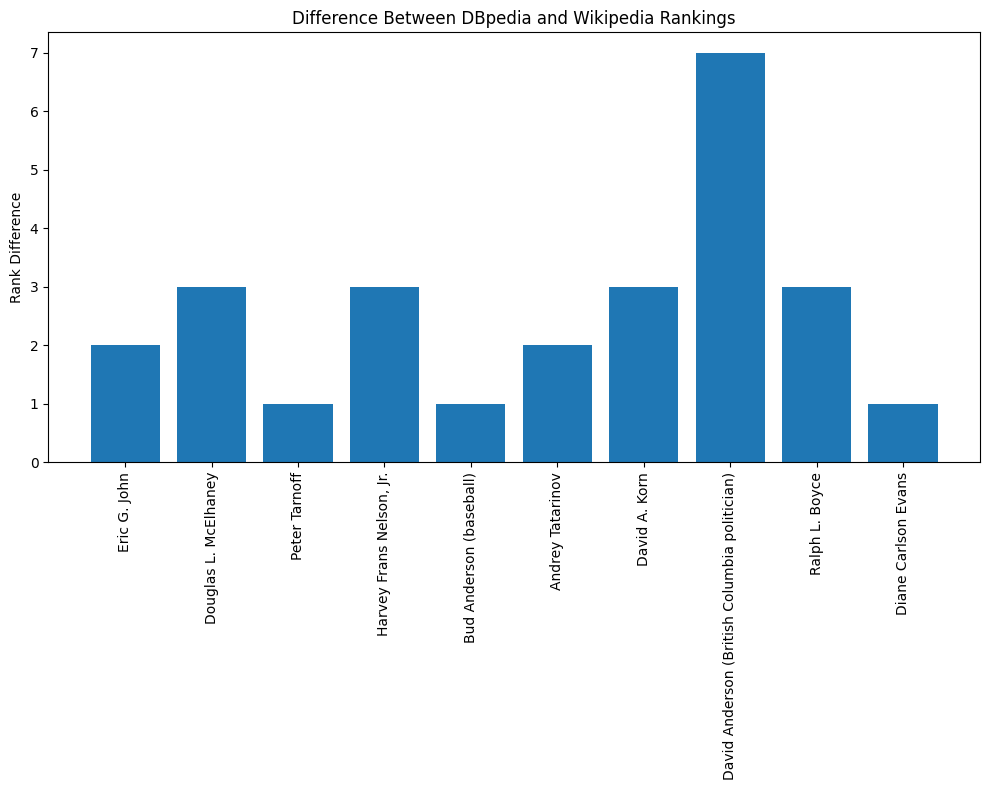

In [79]:
#Plot the Comparison
plt.figure(figsize=(10,8))

plt.bar(
    comparison['Name'],
    comparison['Rank Difference']
)

plt.xticks(rotation=90)
plt.ylabel('Rank Difference')
plt.title('Difference Between DBpedia and Wikipedia Rankings')

plt.tight_layout()
plt.show()

###**How to explain: **

1. **DBpedia Overview** → Short biographies.
2. **Wikipedia Articles** → Full biographies with much more context.
3. **Question:** Does more information change who is considered "most similar"?
4. **Answer:** Compare the rankings and discuss the differences.

##Part 3 - Interactive Notebook

Make an interactive notebook where a user can choose or enter a name and the notebook displays the 10 closest individuals.

In addition to presenting the project slides, at the end of the presentation each student will demonstrate their code using a famous person suggested by the other students that exists in the DBpedia set.

In [93]:
!curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv | wc -l

42786


In [94]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -1 |
tr , '\n' |
cat -n

     1	URI
     2	name
     3	text


In [95]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -2 |
tail -1 |
tr , '\n' |
cat -n

     1	<http://dbpedia.org/resource/Digby_Morrell>
     2	Digby Morrell
     3	digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie draft as a forward he twice kicked five goals during his time with the kangaroos the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell was traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 games for the blues before being delisted at the end of 2005 he continued to play v

In [117]:
#Create a function
def find_similar_people(person_name):

  #Check if the person exists
  if person_name not in df['name'].values:
    print(f"'{person_name}' was not found in the dataset.")
    return

  #Find the reference person's index
  reference_index = df[df['name'] == person_name].index[0]

  #Find the 10 nearest neighbors
  distances, indices = knn.kneighbors(tfidf_matrix[reference_index])

  #Get the reference person's bigraphy
  reference_text = df.loc[df['name'] == person_name, 'text'].iloc[0]

  #Sentiment Analysis
  blob = TextBlob(reference_text)

  #Create results DataFrame
  results = pd.DataFrame({
      'Name': df.iloc[indices[0][1:]]['name'].values,
      'Distance': distances[0][1:]
  })

  #Display results
  print('=' * 60)
  print(f"Reference Person: {person_name}")
  print('=' * 60)
  print(f'Polarity: {blob.sentiment.polarity:.3f}')
  print(f'Subjectivity: {blob.sentiment.subjectivity:.3f}')
  print()
  print('10 Closest Individuals')
  display(results)

#Create dropdown list
dropdown = widgets.Dropdown(
    options=sorted(df['name'].unique()),
    description='Person:',
    layout=widgets.Layout(width='450px')
)

#Create button
button = widgets.Button(
    description='Find Similar People',
    button_style='success'
)

#Button action
def on_button_clicked(b):
  find_similar_people(dropdown.value)

button.on_click(on_button_clicked)

#Display widgets
display(dropdown)
display(button)

Dropdown(description='Person:', layout=Layout(width='450px'), options=(' Renate Lorenz', '%C3%80lex Rigola', '…

Button(button_style='success', description='Find Similar People', style=ButtonStyle())

Reference Person: %C3%89dgar Vivar
Polarity: 0.104
Subjectivity: 0.371

10 Closest Individuals


,Name,Distance
0,Erik Chopin,0.883290
1,Mar%C3%ADa Luisa Alcal%C3%A1,0.892812
2,Efra%C3%ADn L%C3%B3pez Neris,0.905025
3,Gerard Musante,0.905579
4,Sheyla Tadeo,0.906892
5,Eduardo Capetillo,0.909565
6,Joselito (singer),0.911424
7,Clara S%C3%A1nchez (writer),0.912920
8,Guillermo Schmidhuber,0.915815
9,Eduardo Mendoza Garriga,0.916479


#THINGS TO CONSIDER

This is an unsupervised clustering problem.


Data Cleaning
- pluras
- special characters
- numbers


Should I try a:
- k-means
- dbscan
- something else

Part 1:
- What kind of distance did you use?
- Why did you opt for that instead of Euclidean?

Part 2: How do you automate it?
- What if I started scaling it? Start with 20 and scale up.
- n-grams n^1, n^2, n^3...